# Prepare data for Gorkha Earthquake Model
The original data files for this model need to be modified slightly before use with geodef.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import geodef

%load_ext autoreload
%autoreload 2

---

## 1. Mesh from tri+ned files


In [2]:
# the original .ned values are in local N,E,D coordinates but we need them to be geographic for 
ned_data = np.loadtxt('fault/qiu+15_1.ned')
id = ned_data[:,0]
n = ned_data[:,1]
e = ned_data[:,2]
d = ned_data[:,3]

# the original center coordinates used for the projection:
lat0 = 28.155
lon0 = 84.72

lat,lon,_ = geodef.transforms.enu2geod(e,n,0,lat0,lon0,0)

ned_out = np.column_stack((id,lat,lon,d))
np.savetxt('fault/qiu+15_geo.ned',ned_out)

# the .tri file has extra columns. We need just tri_id,v1,v2,v3.
tri_data = np.loadtxt('fault/qiu+15_1.tri')
tri_out = np.column_stack((tri_data[:,0],tri_data[:,2],tri_data[:,3],tri_data[:,4]))
np.savetxt('fault/qiu+15_geo.tri',tri_out)


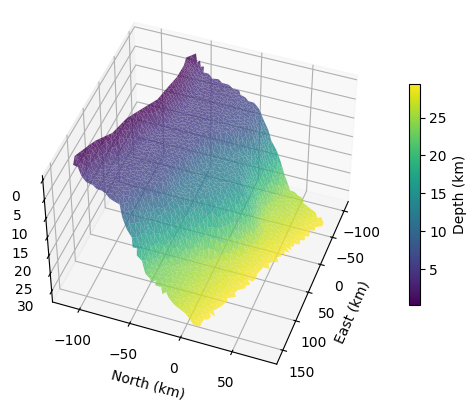

Fault(n_patches=2841, engine='tri')


In [3]:
# once the file conversions have been done, we can load the fault model in one line:
fault=geodef.fault.Fault.load('fault/qiu+15_geo',format="ned")

# visualize fault in 3d
geodef.plot.fault3d(fault,
    color_by='depth',       # 'depth', 'area', 1-D array, or None
    cmap='viridis',
    show_edges=False,
    view=(45, 20),         # (elevation, azimuth) in degrees; None = matplotlib default
)
plt.show()
print(fault)

---
## 2. Load GNSS and InSAR data


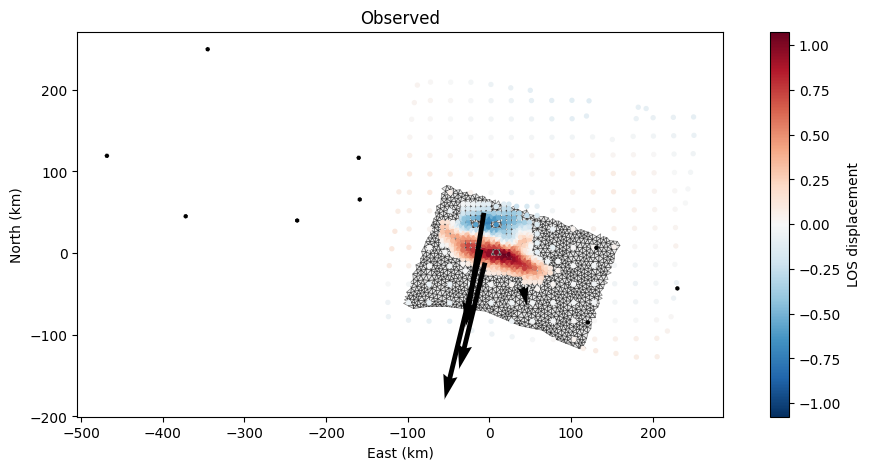

In [ ]:
# there are site names in the GNSS data file, 
# so np.genfromtxt with dtype=None is the easiest way to load the data:
gnss_txt = np.genfromtxt('data/20150425Nepal_ARIA_Final_Offsets_v4.txt', comments='#', dtype=None,
                     names=['Lat','Lon','Site','E','N','U','E_sig','N_sig','U_sig'])

# create the geodef.data object: here, the /100 converts units from cm to m
# CAUTION: YOU MUST CHECK YOUR OWN DATASET'S UNITS!! 
# This is the most common source of error when getting started.
gnss = geodef.data.GNSS(lon=gnss_txt['Lon'],lat=gnss_txt['Lat'],
                        ve=gnss_txt['E']/100,vn=gnss_txt['N']/100,vu=gnss_txt['U']/100,
                        se=gnss_txt['E_sig']/100,sn=gnss_txt['N_sig']/100,su=gnss_txt['U_sig']/100
)

# save data in the format expected by geodef [lon lat hgt uE uN uZ sigE sigN sigZ].
gnss.save('data/aria_offsets_for_geodef.dat')

# same approach for InSAR - no site names in this data, so loadtxt works fine
# Columns in this file are:
# 0.     1.   2.   3.   4.    5.   6.  7.  8.   9.   10. 
# Number xind yind east north data err wgt Elos Nlos Ulos
insar_txt = np.loadtxt('data/varres_T048_insar.txt')

# for the geodef constructor we need: lon, lat, los_values, sigma, look_e, look_n, look_u
# here, /1e3 converts from mm to m
# AGAIN, CAUTION!
insar=geodef.data.InSAR(lon=insar_txt[:,3],lat=insar_txt[:,4],los=insar_txt[:,5]/1e3,sigma=insar_txt[:,6]/1e3,
                        look_e=insar_txt[:,8],look_n=insar_txt[:,9],look_u=insar_txt[:,10]
)

# save: lon, lat, los, sigma, look_e, look_n, look_u
insar.save('data/t048_insar_for_geodef.dat')

# plot the data and fault together
fig,ax = plt.subplots(figsize=(12,5))
geodef.plot.map(fault,ax=ax)
geodef.plot.insar(insar,fault,ax=ax)
geodef.plot.vectors(gnss,fault,ax=ax,scale=100)
plt.show()